# 01 — Analyse exploratoire — Bâtiments de Seattle 2016

**Projet :** OPC6 - Anticipez les besoins en consommation de bâtiments  
**Auteur :** ANNONAY Paul-Alexandre  
**Objectif :** Comprendre la structure du dataset, filtrer aux bâtiments non résidentiels, identifier la target, repérer les colonnes pertinentes et produire un dataset nettoyé pour la phase de modélisation.

**Source :** [Seattle Open Data — Building Energy Benchmarking 2015-Present](https://data.seattle.gov/Built-Environment/Building-Energy-Benchmarking-Data-2015-Present/teqw-tu6e/about_data)

## 1. Setup

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration affichage
pd.set_option("display.max_columns", None)      # afficher toutes les colonnes
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)  # 1 234 567.89
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 2.3.3 | numpy 2.4.4


In [37]:
# Chemin du dataset (par rapport à la racine du repo)
DATA_PATH = Path("..") / "data" / "raw" / "2016_Building_Energy_Benchmarking.csv"

# Chargement
df_raw = pd.read_csv(DATA_PATH)

# Snapshot brut (on travaillera sur une copie pour pouvoir revenir au brut)
df = df_raw.copy()

print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dataset chargé : 3,376 lignes × 46 colonnes


## 2. Vue d'ensemble brute

Objectif : se faire une idée du contenu du dataset avant tout filtrage. On regarde :
- les premières lignes pour comprendre comment est défini un bâtiment ;
- les types de colonnes et le nombre de valeurs non nulles ;
- les statistiques descriptives des variables numériques.

In [38]:
df.head(3)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,0,88434,Hotel,Hotel,"88,434.00",NaN,NaN,NaN,NaN,NaN,60.00,81.70,84.30,182.50,189.00,"7,226,362.50","7,456,910.00","2,003,882.00","1,156,514.25","3,946,027.00","12,764.53","1,276,453.00",False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,"83,880.00",Parking,"15,064.00",Restaurant,"4,622.00",NaN,61.00,94.80,97.90,176.10,179.40,"8,387,933.00","8,664,479.00",0.00,"950,425.19","3,242,851.00","51,450.82","5,145,082.00",False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,"98,101.00",0659000475,7,DOWNTOWN,47.61,-122.34,1969,1.00,41,956110,196718,759392,Hotel,Hotel,"756,493.00",NaN,NaN,NaN,NaN,NaN,43.00,96.00,97.70,241.90,244.10,"72,587,024.00","73,937,112.00","21,566,554.00","14,515,435.00","49,526,664.00","14,938.00","1,493,800.00",False,NaN,Compliant,NaN,"2,089.28",2.19


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [40]:
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,"3,376.00","3,376.00","3,360.00","3,376.00","3,376.00","3,376.00","3,376.00","3,368.00","3,376.00","3,376.00","3,376.00","3,376.00","3,356.00","1,679.00",596.00,"2,533.00","3,369.00","3,370.00","3,367.00","3,367.00","3,371.00","3,370.00","3,367.00","3,367.00","3,367.00","3,367.00","3,367.00",0.00,"3,367.00","3,367.00"
mean,"21,208.99","2,016.00","98,116.95",4.44,47.62,-122.33,"1,968.57",1.11,4.71,"94,833.54","8,001.53","86,832.01","79,177.64","28,444.08","11,738.68",67.92,54.73,57.03,134.23,137.78,"5,403,667.29","5,276,725.71","274,595.90","1,086,638.97","3,707,612.16","13,685.05","1,368,504.54",NaN,119.72,1.18
std,"12,223.76",0.00,18.62,2.12,0.05,0.03,33.09,2.11,5.49,"218,837.61","32,326.72","207,939.81","201,703.41","54,392.92","29,331.20",26.87,56.27,57.16,139.29,139.11,"21,610,628.63","15,938,786.48","3,912,173.39","4,352,478.36","14,850,656.14","67,097.81","6,709,780.83",NaN,538.83,1.82
min,1.00,"2,016.00","98,006.00",1.00,47.50,-122.41,"1,900.00",0.00,0.00,"11,285.00",0.00,"3,636.00","5,656.00",0.00,0.00,1.00,0.00,0.00,0.00,-2.10,0.00,0.00,0.00,"-33,826.80","-115,417.00",0.00,0.00,NaN,-0.80,-0.02
25%,"19,990.75","2,016.00","98,105.00",3.00,47.60,-122.35,"1,948.00",1.00,2.00,"28,487.00",0.00,"27,756.00","25,094.75","5,000.00","2,239.00",53.00,27.90,29.40,74.70,78.40,"925,128.59","970,182.23",0.00,"187,422.95","639,487.00",0.00,0.00,NaN,9.50,0.21
50%,"23,112.00","2,016.00","98,115.00",4.00,47.62,-122.33,"1,975.00",1.00,4.00,"44,175.00",0.00,"43,216.00","39,894.00","10,664.00","5,043.00",75.00,38.60,40.90,96.20,101.10,"1,803,753.25","1,904,452.00",0.00,"345,129.91","1,177,583.00","3,237.54","323,754.00",NaN,33.92,0.61
75%,"25,994.25","2,016.00","98,122.00",7.00,47.66,-122.32,"1,997.00",1.00,5.00,"90,992.00",0.00,"84,276.25","76,200.25","26,640.00","10,138.75",90.00,60.40,64.28,143.90,148.35,"4,222,455.25","4,381,429.12",0.00,"829,317.84","2,829,632.50","11,890.33","1,189,033.50",NaN,93.94,1.37
max,"50,226.00","2,016.00","98,272.00",7.00,47.73,-122.22,"2,015.00",111.00,99.00,"9,320,156.00","512,608.00","9,320,156.00","9,320,156.00","686,750.00","459,748.00",100.00,834.40,834.40,"2,620.00","2,620.00","873,923,712.00","471,613,856.00","134,943,456.00","192,577,488.00","657,074,389.00","2,979,090.00","297,909,000.00",NaN,"16,870.98",34.09


In [41]:
df.describe(include="object")

,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,TaxParcelIdentificationNumber,Neighborhood,ListOfAllPropertyUseTypes,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,YearsENERGYSTARCertified,ComplianceStatus,Outlier
count,3376,3376,3376,3376,3376,3376,3376,3376,3367,3356,1679,596,119,3376,32
unique,8,24,3362,3354,1,1,3268,19,466,56,50,44,65,4,2
top,NonResidential,Low-Rise Multifamily,Northgate Plaza,2600 SW Barton St,Seattle,WA,1625049001,DOWNTOWN,Multifamily Housing,Multifamily Housing,Parking,Retail Store,2016,Compliant,Low outlier
freq,1460,987,3,4,3376,3376,8,573,866,1667,976,110,14,3211,23


### Premières observations

- Le dataset brut contient **3 376 lignes × 46 colonnes**, couvrant à la fois des bâtiments résidentiels et non résidentiels — un filtrage par `BuildingType` sera nécessaire avant toute analyse.
- Les variables **numériques** sont globalement très bien renseignées (> 99 % de complétude pour la plupart, y compris les variables énergétiques critiques).
- Les variables **catégorielles** sont elles aussi bien renseignées, à l'exception de quelques colonnes spécifiques.
- **Point d'attention sur les colonnes faiblement remplies :** la plupart correspondent à des NA **structurels** (information non applicable à certains bâtiments) plutôt qu'à des données manquantes :
  - `SecondLargestPropertyUseType` / `ThirdLargestPropertyUseType` : NA = bâtiment mono-usage → transformables en features binaires `has_second_use`, `has_third_use`.
  - `Outlier` : NA = bâtiment non-flaggé comme outlier → exploitable pour filtrer.
  - `YearsENERGYSTARCertified` : NA = bâtiment non certifié → transformable en feature binaire.
- `Comments` est totalement vide (0 valeur non-nulle) → drop.
- Quelques colonnes ont de rares NA "manqués" (`ZipCode`, `NumberofBuildings`, `LargestPropertyUseType`…) qui justifieront un drop de quelques lignes ou une imputation simple.
- **Bilan :** seul `ENERGYSTARScore` (843 NA, 75 % de remplissage) demandera une vraie réflexion (imputation vs drop colonne) ; les autres ont un traitement assez direct.

## 2.bis. Investigation : ENERGYSTARScore vs YearsENERGYSTARCertified

Avant de filtrer le dataset, on creuse une apparente incohérence : 75 % des bâtiments ont un `ENERGYSTARScore` mais seulement 4 % ont une valeur dans `YearsENERGYSTARCertified`.

**Hypothèse à vérifier :**
- `ENERGYSTARScore` = note attribuée automatiquement par l'EPA (peut exister sans démarche).
- `YearsENERGYSTARCertified` = certification volontaire (démarche du propriétaire, conditionnée à un score ≥ 75).

Si l'hypothèse est correcte, on devrait observer :
1. Tous les bâtiments certifiés ont un score.
2. Tous les bâtiments certifiés ont un score ≥ 75 (seuil officiel EPA).
3. L'absence de score n'est pas aléatoire : elle est liée au type d'usage du bâtiment (catégories non éligibles au programme ENERGY STAR).

In [42]:
# Vérification 1 : tous les bâtiments certifiés ont-ils un score ?
mask_certified = df["YearsENERGYSTARCertified"].notna()
n_certified = mask_certified.sum()
n_certified_with_score = (mask_certified & df["ENERGYSTARScore"].notna()).sum()

print(f"Bâtiments certifiés                       : {n_certified}")
print(f"Parmi eux, ayant un ENERGYSTARScore       : {n_certified_with_score}")
print(f"Parmi eux, SANS ENERGYSTARScore           : {n_certified - n_certified_with_score}")

Bâtiments certifiés                       : 119
Parmi eux, ayant un ENERGYSTARScore       : 117
Parmi eux, SANS ENERGYSTARScore           : 2


In [43]:
# Vérification 2 : les bâtiments certifiés ont-ils tous un score ≥ 75 ?
df.loc[mask_certified, "ENERGYSTARScore"].describe()

count   117.00
mean     85.26
std      14.61
min       3.00
25%      81.00
50%      89.00
75%      95.00
max     100.00
Name: ENERGYSTARScore, dtype: float64

In [44]:
# Vérification 3 : les NA de score sont-ils concentrés sur certains types d'usage ?
df.groupby("PrimaryPropertyType")["ENERGYSTARScore"].agg(
    n_total="size",
    n_with_score=lambda s: s.notna().sum(),
    pct_with_score=lambda s: f"{s.notna().mean():.0%}"
).sort_values("n_total", ascending=False)

,n_total,n_with_score,pct_with_score
PrimaryPropertyType,,,
Low-Rise Multifamily,987,847,86%
Mid-Rise Multifamily,564,462,82%
Small- and Mid-Sized Office,293,239,82%
Other,256,11,4%
Warehouse,187,143,76%
Large Office,173,163,94%
K-12 School,139,125,90%
Mixed Use Property,133,36,27%
High-Rise Multifamily,105,93,89%


### Conclusion de l'investigation

**Hypothèse confirmée :** `ENERGYSTARScore` et `YearsENERGYSTARCertified` mesurent deux choses différentes — un score technique automatique vs un statut de certification volontaire.

**Vérifications concrètes :**
1. **Certification ⊂ Score :** 117 / 119 bâtiments certifiés ont un score (98 %), confirmant que la certification s'appuie sur le score.
2. **Score minimum des certifiés :** médiane à 89 et Q1 à 81, conformes à la règle EPA (certification ≥ 75). Un cas atypique à score 3 (probable certification historique non maintenue).
3. **Absence de score = structurelle :** les types d'usage non couverts par le programme EPA ont systématiquement 0 % de score (Self-Storage, University, Restaurant, Laboratory). Les types éligibles ont 75-100 % de score. Les NA ne sont **pas aléatoires** — ils sont **structurellement liés au type d'usage**.

**Conséquences pratiques pour le feature engineering :**

| Colonne | Décision | Justification |
|---|---|---|
| `ENERGYSTARScore` | **Drop colonne** | Data leakage : le score est calculé à partir de la consommation énergétique mesurée, donc directement dérivé de la target |
| `YearsENERGYSTARCertified` | **Transformer en feature binaire `is_energy_star_certified`** | La certification est un statut administratif (démarche volontaire du propriétaire), pas une mesure directe — feature légitime |

*Décisions tracées dans `DECISIONS.md`.*

## 3. Filtrage des bâtiments non résidentiels

La consigne impose de **ne conserver que les bâtiments non destinés à l'habitation**. La colonne `BuildingType` contient plusieurs catégories qu'il faut analyser pour décider du périmètre exact.

**Démarche :**
1. Lister toutes les valeurs distinctes de `BuildingType`.
2. Identifier celles qui correspondent à de l'habitation (à exclure) et celles qui correspondent à du non-résidentiel (à conserver).
3. Filtrer le dataset et tracer les volumes avant/après.

In [45]:
# Inventaire des catégories
df["BuildingType"].value_counts(dropna=False)

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

### Analyse des catégories

À partir de l'inventaire ci-dessus, on classe chaque valeur :

| Catégorie | Nature | Décision |
|---|---|---|
| `NonResidential` | Bureaux, commerces, etc. | ✅ Conserver |
| `Nonresidential COS` | "City Of Seattle" — bâtiments municipaux non résidentiels | ✅ Conserver |
| `Nonresidential WA` | "Washington State" — bâtiments d'état non résidentiels | ✅ Conserver |
| `SPS-District K-12` | Écoles publiques de Seattle (Seattle Public Schools) | ✅ Conserver — ce sont des établissements, pas des habitations |
| `Campus` | Universités / grands campus | ✅ Conserver — usage non résidentiel |
| `Multifamily LR (1-4)` | Habitat collectif Low-Rise | ❌ Exclure — habitation |
| `Multifamily MR (5-9)` | Habitat collectif Mid-Rise | ❌ Exclure — habitation |
| `Multifamily HR (10+)` | Habitat collectif High-Rise | ❌ Exclure — habitation |

*Choix tracé dans `DECISIONS.md`. À valider avec le mentor en première session.*

In [46]:
# Catégories à conserver (tout ce qui n'est pas Multifamily*)
NON_RESIDENTIAL_TYPES = [
    "NonResidential",
    "Nonresidential COS",
    "Nonresidential WA",
    "SPS-District K-12",
    "Campus",
]

# Snapshot avant/après pour traçabilité
n_before = len(df)
df = df[df["BuildingType"].isin(NON_RESIDENTIAL_TYPES)].copy()
n_after = len(df)

print(f"Lignes avant filtrage : {n_before:,}")
print(f"Lignes après filtrage : {n_after:,}")
print(f"Lignes exclues         : {n_before - n_after:,} ({(n_before - n_after) / n_before:.1%})")

Lignes avant filtrage : 3,376
Lignes après filtrage : 1,668
Lignes exclues         : 1,708 (50.6%)


In [47]:
# Vérification : plus aucun Multifamily dans le dataset filtré
df["BuildingType"].value_counts()

BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

### Observations après filtrage

*À compléter après exécution :*

- Après filtrage, **1 668 bâtiments** sont conservés sur **3 376**, soit environ **49,4 %** du dataset initial.
- Répartition par type :

    | Type | Nombre | % |
    |---|---|---|
    | NonResidential | 1460 | 87.5 |
    | SPS-District K-12 | 98 | 5.9 |
    | Nonresidential COS | 85 | 5.1 |
    | Campus | 24 | 1.4 |
    | Nonresidential WA | 1 | 0 |
- Une remarque : La grande majorité des batiment sont de type `NonResidential`(87.5 %)
- Une question : les différentes catégories de bâtiments non résidentiels ont-elles des comportements énergétiques comparables, ou faudra-t-il tenir compte du type de bâtiment dans la modélisation ?

## 4. Carte des valeurs manquantes (dataset filtré)

Après filtrage, le dataset contient 1 668 lignes. Il faut redresser la carte des NA sur ce périmètre et décider du traitement de chaque colonne, en distinguant :

- **Colonnes vides ou inutilisables** → drop immédiat.
- **Colonnes identifiants** (ID, adresses, noms…) → drop car non prédictives.
- **Colonnes potentielles features** → garder, traiter les NA au cas par cas plus tard.
- **Colonnes target candidates** → analyser leur complétude.

In [48]:
# Carte exhaustive des NA après filtrage
na_summary = pd.DataFrame({
    "n_total": len(df),
    "n_na": df.isna().sum(),
    "pct_na": (df.isna().mean() * 100).round(1),
    "dtype": df.dtypes.astype(str),
})
na_summary = na_summary.sort_values("pct_na", ascending=False)
na_summary

,n_total,n_na,pct_na,dtype
Comments,1668,1668,100.00,float64
Outlier,1668,1651,99.00,object
YearsENERGYSTARCertified,1668,1570,94.10,object
ThirdLargestPropertyUseType,1668,1315,78.80,object
ThirdLargestPropertyUseTypeGFA,1668,1315,78.80,float64
SecondLargestPropertyUseType,1668,813,48.70,object
SecondLargestPropertyUseTypeGFA,1668,813,48.70,float64
ENERGYSTARScore,1668,574,34.40,float64
ZipCode,1668,16,1.00,float64
LargestPropertyUseType,1668,6,0.40,object


### Plan d'action par colonne

À partir de la carte ci-dessus, on classe chaque colonne :

#### A — Colonnes à drop immédiatement (vides ou inutiles)

| Colonne | Raison |
|---|---|
| `Comments` | 100 % NA — vide |
| `OSEBuildingID` | Identifiant unique, non prédictif |
| `DataYear` | Constante (2016 uniquement) — pas d'information |
| `PropertyName` | Nom du bâtiment — non prédictif |
| `Address` | Adresse postale — non prédictif |
| `TaxParcelIdentificationNumber` | Identifiant cadastral — non prédictif |
| `City` | Constante (Seattle) — pas d'information |
| `State` | Constante (WA) — pas d'information |

#### B — Colonnes à drop pour data leakage

| Colonne | Raison |
|---|---|
| `ENERGYSTARScore` | Score calculé à partir de la consommation (cf. `DECISIONS.md`) |
| `SiteEUI(kBtu/sf)` | EUI = `SiteEnergyUse / surface` → dérivé direct de la target |
| `SiteEUIWN(kBtu/sf)` | EUI normalisé météo — idem |
| `SourceEUI(kBtu/sf)` | Idem mais en énergie source |
| `SourceEUIWN(kBtu/sf)` | Idem |
| `Electricity(kBtu)` | Composante directe de `SiteEnergyUse` |
| `Electricity(kWh)` | Idem (même variable en autre unité) |
| `NaturalGas(kBtu)` | Composante directe de `SiteEnergyUse` |
| `NaturalGas(therms)` | Idem |
| `SteamUse(kBtu)` | Composante directe de `SiteEnergyUse` |
| `SiteEnergyUseWN(kBtu)` | Version "normalisée météo" de la target — c'est presque la target |
| `GHGEmissionsIntensity` | Émissions / surface — dérivé de `TotalGHGEmissions` |

#### C — Colonnes à transformer en feature (plus tard, section 9 / phase 3)

| Colonne | Transformation prévue |
|---|---|
| `YearsENERGYSTARCertified` | → `is_energy_star_certified` (binaire) |
| `SecondLargestPropertyUseType` / `GFA` | → `has_second_use` (binaire) ou variables exploitées |
| `ThirdLargestPropertyUseType` / `GFA` | → `has_third_use` (binaire) |
| `ListOfAllPropertyUseTypes` | À analyser ou drop (redondant avec les colonnes Largest/Second/Third) |
| `Outlier` | À utiliser pour filtrer puis drop |
| `DefaultData` | À analyser puis décision |
| `ComplianceStatus` | À analyser puis décision |

#### D — Colonnes à conserver pour la modélisation :

- `BuildingType`,
- `PrimaryPropertyType`,
- `ZipCode`,
- `CouncilDistrictCode`,
- `Neighborhood`,
- `Latitude`,
- `Longitude`,
- `YearBuilt`,
- `NumberofBuildings`,
- `NumberofFloors`,
- `PropertyGFATotal`,
- `PropertyGFAParking`,
- `PropertyGFABuilding(s)`,
- `LargestPropertyUseType`,
- `LargestPropertyUseTypeGFA`.

#### E — Targets candidates

`SiteEnergyUse(kBtu)`, `TotalGHGEmissions` (sera tranchée en section 5).

In [49]:
# Colonnes à drop immédiatement (groupes A + B définis ci-dessus)
COLS_TO_DROP_USELESS = [
    "Comments", "OSEBuildingID", "DataYear", "PropertyName",
    "Address", "TaxParcelIdentificationNumber", "City", "State",
]

COLS_TO_DROP_LEAKAGE = [
    "ENERGYSTARScore",
    "SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)",
    "Electricity(kBtu)", "Electricity(kWh)",
    "NaturalGas(kBtu)", "NaturalGas(therms)",
    "SteamUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
    "GHGEmissionsIntensity",
]

# Vérification que toutes les colonnes existent bien avant de drop
all_to_drop = COLS_TO_DROP_USELESS + COLS_TO_DROP_LEAKAGE
missing = [c for c in all_to_drop if c not in df.columns]
assert not missing, f"Colonnes introuvables : {missing}"

# Drop
n_cols_before = df.shape[1]
df = df.drop(columns=all_to_drop)
n_cols_after = df.shape[1]

print(f"Colonnes avant drop : {n_cols_before}")
print(f"Colonnes après drop : {n_cols_after}")
print(f"Colonnes droppées   : {n_cols_before - n_cols_after}")
print(f"  — inutilisables   : {len(COLS_TO_DROP_USELESS)}")
print(f"  — data leakage    : {len(COLS_TO_DROP_LEAKAGE)}")

Colonnes avant drop : 46
Colonnes après drop : 26
Colonnes droppées   : 20
  — inutilisables   : 8
  — data leakage    : 12


In [50]:
# Nouvelle carte des NA après drop
df.isna().sum().sort_values(ascending=False).head(15)

Outlier                            1651
YearsENERGYSTARCertified           1570
ThirdLargestPropertyUseTypeGFA     1315
ThirdLargestPropertyUseType        1315
SecondLargestPropertyUseTypeGFA     813
SecondLargestPropertyUseType        813
ZipCode                              16
LargestPropertyUseType                6
LargestPropertyUseTypeGFA             6
NumberofBuildings                     2
SiteEnergyUse(kBtu)                   2
TotalGHGEmissions                     2
ListOfAllPropertyUseTypes             2
Latitude                              0
CouncilDistrictCode                   0
dtype: int64

### Observations après drop

*À compléter après exécution :*

- Après suppression des colonnes inutiles et des colonnes à risque de data leakage, le dataset passe de **46 à 26 colonnes**.  
  Au total, **20 colonnes ont été supprimées** : 8 colonnes inutilisables ou non prédictives et 12 colonnes liées au data leakage.
- Les valeurs manquantes restantes sont surtout concentrées dans des colonnes qui ont un sens métier particulier.  
  Par exemple, `Outlier` contient beaucoup de NA, mais cela peut simplement indiquer que le bâtiment n’a pas été signalé comme atypique.  
  De même, `YearsENERGYSTARCertified` est très peu renseignée, probablement parce que la majorité des bâtiments ne sont pas certifiés.  
  Les colonnes liées au deuxième et troisième usage du bâtiment ont aussi beaucoup de NA, ce qui semble logique : tous les bâtiments n’ont pas plusieurs usages déclarés.  
  En revanche, les quelques NA restants sur `ZipCode`, `LargestPropertyUseType`, `LargestPropertyUseTypeGFA`, `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` devront être traités avant la modélisation.
- Ce qui surprend surtout, c’est la présence de 2 valeurs manquantes sur les targets candidates `SiteEnergyUse(kBtu)` et `TotalGHGEmissions`.  
  La question à se poser est donc : faut-il supprimer ces lignes avant la modélisation, puisqu’il sera impossible d’entraîner un modèle supervisé sur des observations sans valeur cible ?

## 5. Analyse des targets candidates

### Contexte décisionnel

La consigne présente une **ambiguïté** sur la cible :

- **Brief de Douglas :** *« vous voulez tenter de prédire les émissions de CO2 et la consommation totale d'énergie »* → laisse entendre **deux cibles**.
- **Instruction technique plus loin :** *« faites le choix d'une seule target et conservez-la pour le projet »* → impose **une cible**.

**Décision provisoire : stratégie défensive.** On garde les deux candidates dans le dataset jusqu'à validation par le mentor en 1ʳᵉ session, avec hypothèse de travail privilégiée `SiteEnergyUse(kBtu)`. Cette section produit l'analyse comparative nécessaire pour défendre n'importe quel choix final.

**Candidates :**
- `SiteEnergyUse(kBtu)` — consommation totale d'énergie sur site.
- `TotalGHGEmissions` — émissions totales de gaz à effet de serre.

In [51]:
# Statistiques descriptives des deux candidates
df[["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]].describe()

,SiteEnergyUse(kBtu),TotalGHGEmissions
count,"1,666.00","1,666.00"
mean,"8,437,933.22",184.97
std,"30,243,803.39",751.98
min,0.00,-0.80
25%,"1,229,290.84",19.97
50%,"2,554,947.25",49.58
75%,"6,913,348.50",142.38
max,"873,923,712.00","16,870.98"


In [52]:
# NA et valeurs problématiques
for col in ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]:
    n_na = df[col].isna().sum()
    n_zero = (df[col] == 0).sum()
    n_neg = (df[col] < 0).sum()
    print(f"{col}")
    print(f"  NA       : {n_na}")
    print(f"  Zéros    : {n_zero}")
    print(f"  Négatifs : {n_neg}")
    print()

SiteEnergyUse(kBtu)
  NA       : 2
  Zéros    : 16
  Négatifs : 0

TotalGHGEmissions
  NA       : 2
  Zéros    : 6
  Négatifs : 1



In [53]:
# Les lignes sans SiteEnergyUse sont-elles les mêmes que celles sans TotalGHGEmissions ?
mask_no_energy = df["SiteEnergyUse(kBtu)"].isna()
mask_no_ghg = df["TotalGHGEmissions"].isna()

print(f"Lignes sans SiteEnergyUse(kBtu)         : {mask_no_energy.sum()}")
print(f"Lignes sans TotalGHGEmissions           : {mask_no_ghg.sum()}")
print(f"Lignes sans NI l'un NI l'autre          : {(mask_no_energy & mask_no_ghg).sum()}")
print(f"Lignes sans l'un OU l'autre             : {(mask_no_energy | mask_no_ghg).sum()}")

Lignes sans SiteEnergyUse(kBtu)         : 2
Lignes sans TotalGHGEmissions           : 2
Lignes sans NI l'un NI l'autre          : 2
Lignes sans l'un OU l'autre             : 2


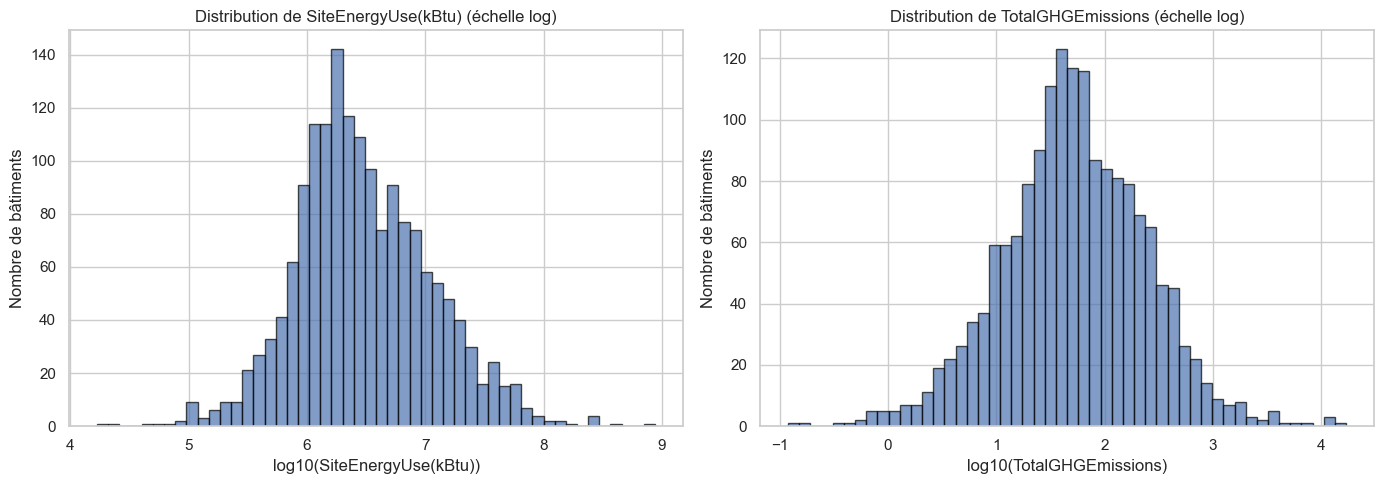

In [54]:
# Distribution des deux candidates (échelle log car forte dispersion attendue)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]):
    # On filtre les NA et les zéros/négatifs pour la visualisation en log
    data = df[col].dropna()
    data_pos = data[data > 0]
    ax.hist(np.log10(data_pos), bins=50, edgecolor="black", alpha=0.7)
    ax.set_xlabel(f"log10({col})")
    ax.set_ylabel("Nombre de bâtiments")
    ax.set_title(f"Distribution de {col} (échelle log)")

plt.tight_layout()
plt.show()

In [55]:
# Corrélation entre les deux candidates
corr = df[["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]].corr().iloc[0, 1]
print(f"Corrélation Pearson entre SiteEnergyUse(kBtu) et TotalGHGEmissions : {corr:.3f}")

Corrélation Pearson entre SiteEnergyUse(kBtu) et TotalGHGEmissions : 0.860


### Analyse comparative

*À compléter après exécution des cellules ci-dessus.*

**Synthèse des deux candidates :**

| Critère | `SiteEnergyUse(kBtu)` | `TotalGHGEmissions` |
|---|---|---|
| NA | 2 | 2 |
| Valeurs à zéro | 16 | 6 |
| Valeurs négatives | 0 | 1 |
| Médiane | 2 554 947.25 | 49.58 |
| Min / Max | 0 / 873 923 712 | -0.8 / 16 870.98 |
| Échelle de distribution | Très dispersée, mieux lisible en log | Très dispersée, mieux lisible en log |
| Corrélation entre les deux | Forte corrélation : 0.860 | - |
| Lien aux features structurelles | direct (taille, usage, isolation) | indirect (passe par le mix énergétique) |

**Lecture des résultats :**

- Si on garde uniquement SiteEnergyUse(kBtu), il faut supprimer 2 lignes ayant une target manquante.  
  Si on garde les deux targets, il faut aussi supprimer 2 lignes, car les valeurs manquantes sont sur les mêmes observations.
- La corrélation de Pearson est de 0,860, ce qui indique une forte corrélation positive entre la consommation énergétique et les émissions de gaz à effet de serre.
- Oui, les deux distributions deviennent beaucoup plus lisibles en échelle logarithmique.  
  Elles présentent toutes les deux une forte dispersion, avec quelques valeurs extrêmes, mais leur forme générale est assez comparable après transformation log.

**Décision actuelle (provisoire) :** stratégie défensive — on conserve les deux variables dans le dataset, ainsi que les lignes ayant **au moins l'une des deux** renseignées. Verdict mentor attendu pour trancher entre :
- Cible unique `SiteEnergyUse(kBtu)` (drop de `TotalGHGEmissions`).
- Cible unique `TotalGHGEmissions` (drop de `SiteEnergyUse`) — peu probable.
- Modélisation des deux (multi-output ou deux pipelines).

*Décision tracée dans `DECISIONS.md`.*

In [56]:
# Drop UNIQUEMENT des lignes qui n'ont AUCUNE target renseignée
# (une ligne avec consommation mais sans CO2 reste utilisable pour la modélisation énergie, et inversement)
n_before = len(df)
df = df[df["SiteEnergyUse(kBtu)"].notna() | df["TotalGHGEmissions"].notna()].copy()
n_after = len(df)

print(f"Lignes avant drop des targets totalement NA : {n_before:,}")
print(f"Lignes après drop                            : {n_after:,}")
print(f"Lignes supprimées                            : {n_before - n_after}")

Lignes avant drop des targets totalement NA : 1,668
Lignes après drop                            : 1,666
Lignes supprimées                            : 2


In [57]:
# Combien de bâtiments avec target = 0 sur chacune des deux ?
for col in ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]:
    n_zero = (df[col] == 0).sum()
    print(f"Bâtiments avec {col} = 0 : {n_zero}")

# Inspection des bâtiments à consommation 0 (s'il y en a)
if (df["SiteEnergyUse(kBtu)"] == 0).any():
    print("\nÉchantillon des bâtiments à SiteEnergyUse = 0 :")
    print(
        df[df["SiteEnergyUse(kBtu)"] == 0]
        [["BuildingType", "PrimaryPropertyType", "PropertyGFATotal",
          "SiteEnergyUse(kBtu)", "TotalGHGEmissions"]]
        .head(20)
    )
if (df["TotalGHGEmissions"] == 0).any():
    print("\nÉchantillon des bâtiments à TotalGHGEmissions = 0 :")
    print(
        df[df["TotalGHGEmissions"] == 0]
        [["BuildingType", "PrimaryPropertyType", "PropertyGFATotal",
          "SiteEnergyUse(kBtu)", "TotalGHGEmissions"]]
        .head(20)
    )

Bâtiments avec SiteEnergyUse(kBtu) = 0 : 16
Bâtiments avec TotalGHGEmissions = 0 : 6

Échantillon des bâtiments à SiteEnergyUse = 0 :
           BuildingType PrimaryPropertyType  PropertyGFATotal  SiteEnergyUse(kBtu)  TotalGHGEmissions
28    SPS-District K-12         K-12 School            126351                 0.00               0.00
31    SPS-District K-12         K-12 School             51582                 0.00              10.43
62    SPS-District K-12         K-12 School             53352                 0.00               4.19
81    SPS-District K-12         K-12 School             74468                 0.00              11.84
85    SPS-District K-12         K-12 School             58933                 0.00              16.36
95    SPS-District K-12         K-12 School             66588                 0.00              14.67
133   SPS-District K-12         K-12 School            160270                 0.00             229.38
139   SPS-District K-12         K-12 School       

### Observations sur les bâtiments à consommation nulle

- Après suppression des lignes sans aucune target renseignée, le dataset contient 1 666 bâtiments.  
  Parmi eux, 16 bâtiments ont une consommation totale égale à 0 (`SiteEnergyUse(kBtu)`) et 6 bâtiments ont des émissions égales à 0 (`TotalGHGEmissions`).
- Les bâtiments concernés sont principalement des bâtiments de type SPS-District K-12, associés à la catégorie K-12 School. On trouve aussi quelques bâtiments NonResidential, notamment avec le type Other, et un cas de Supermarket / Grocery Store avec une consommation renseignée mais des émissions à 0.  
  Ces valeurs semblent plutôt suspectes : un bâtiment avec une surface importante et une consommation énergétique à 0 paraît peu réaliste, sauf cas particulier comme un bâtiment vacant, fermé, en travaux ou mal renseigné.  
  Certaines incohérences apparaissent aussi, par exemple des bâtiments avec une consommation à 0 mais des émissions positives, ou inversement une consommation positive mais des émissions à 0.
- Ces lignes seront conservées temporairement, mais elles devront être analysées dans la section dédiée aux outliers et au nettoyage qualité. Il faudra décider si ces valeurs à 0 correspondent à de vrais cas métier ou à des anomalies à corriger/supprimer avant la modélisation.

## 6. Traitement des outliers et nettoyage qualité

L'analyse des sections précédentes a fait apparaître plusieurs cas problématiques :
- Outliers pré-flaggés par Seattle dans la colonne `Outlier`.
- Bâtiments avec une consommation totale à 0 (16 cas).
- Bâtiments avec des émissions à 0 (6 cas) ou négatives (1 cas).
- NA résiduels sur quelques features critiques (`ZipCode`, `LargestPropertyUseType`, `NumberofBuildings`).

Objectif de cette section : **filtrer le dataset de toutes les anomalies** avant d'aborder le feature engineering, en gardant trace des comptages à chaque étape.

In [58]:
# Inventaire des bâtiments flaggés comme outliers par Seattle
df["Outlier"].value_counts(dropna=False)

Outlier
NaN             1649
Low outlier       15
High outlier       2
Name: count, dtype: int64

### 6.1. Outliers pré-flaggés par Seattle

La colonne `Outlier` est renseignée par Seattle pour les bâtiments dont les données ont été identifiées comme atypiques après contrôle qualité. Les bâtiments **non-flaggés** ont une valeur NA — c'est le comportement nominal.

**Décision :** drop des bâtiments flaggés (any valeur non-NA). C'est une décision **objective** (basée sur le contrôle qualité de l'autorité émettrice du dataset) et donc facile à défendre.

In [59]:
# Drop des bâtiments flaggés comme outliers
n_before = len(df)
df = df[df["Outlier"].isna()].copy()
n_after = len(df)

print(f"Lignes avant drop outliers Seattle : {n_before:,}")
print(f"Lignes après drop outliers Seattle : {n_after:,}")
print(f"Outliers supprimés                  : {n_before - n_after}")

Lignes avant drop outliers Seattle : 1,666
Lignes après drop outliers Seattle : 1,649
Outliers supprimés                  : 17


### 6.2. Bâtiments à consommation ou émissions anormales

On a identifié en section 5 :
- 16 bâtiments avec `SiteEnergyUse(kBtu) = 0`.
- 6 bâtiments avec `TotalGHGEmissions = 0`.
- 1 bâtiment avec `TotalGHGEmissions < 0`.

**Analyse :**

| Cas | Volumétrie | Diagnostic |
|---|---|---|
| Consommation totale = 0 | 16 | Incohérent pour des bâtiments de cette taille (jusqu'à 1.4M sqft). Probablement bâtiments vacants, en travaux, ou erreurs de saisie. Plusieurs présentent une consommation à 0 mais des émissions positives → inconsistance interne. |
| Émissions = 0 | 6 | Cas extrême : aucune émission rapportée. Incohérent quand la consommation est positive. |
| Émissions < 0 | 1 | Valeur de -0.80 — physiquement impossible. Probable arrondi de comptabilité carbone. |

**Décision :** drop de toutes ces lignes. Ce sont des observations dont les données ne peuvent pas servir à l'entraînement d'un modèle prédictif fiable.

**Note :** la stratégie défensive nous force à drop sur les **deux** targets — si on filtre seulement sur l'énergie, on garde les émissions à 0 ou négatives qui empêcheraient la modélisation des émissions si mentor valide l'option C.

In [60]:
# Drop des lignes avec valeurs nulles ou négatives sur l'une ou l'autre target
n_before = len(df)

# On garde uniquement les lignes où :
# - SiteEnergyUse est > 0 (strictement)
# - TotalGHGEmissions est > 0 (strictement)
# - Les deux conditions doivent être vraies pour préserver la stratégie défensive
mask_valid = (df["SiteEnergyUse(kBtu)"] > 0) & (df["TotalGHGEmissions"] > 0)
df = df[mask_valid].copy()

n_after = len(df)
n_dropped = n_before - n_after

print(f"Lignes avant drop valeurs anormales : {n_before:,}")
print(f"Lignes après drop                    : {n_after:,}")
print(f"Lignes supprimées                    : {n_dropped}")

Lignes avant drop valeurs anormales : 1,649
Lignes après drop                    : 1,631
Lignes supprimées                    : 18


### 6.3. Conformité de la déclaration énergétique

La colonne `ComplianceStatus` indique si le bâtiment est en conformité avec l'obligation déclarative de Seattle. Les bâtiments non conformes ont potentiellement des données partiellement renseignées ou estimées.

In [61]:
df["ComplianceStatus"].value_counts(dropna=False)

ComplianceStatus
Compliant                       1546
Error - Correct Default Data      85
Name: count, dtype: int64

In [62]:
# Croisement entre ComplianceStatus et DefaultData
pd.crosstab(
    df["ComplianceStatus"],
    df["DefaultData"],
    margins=True,
    margins_name="Total",
)

DefaultData,False,True,Total
ComplianceStatus,,,
Compliant,1546,0,1546
Error - Correct Default Data,0,85,85
Total,1546,85,1631


In [63]:
# Si on dropait les "Error - Correct Default Data", quelle perte sur la target ?
mask_compliant = df["ComplianceStatus"] == "Compliant"
mask_error = df["ComplianceStatus"] == "Error - Correct Default Data"

print("Statistiques SiteEnergyUse(kBtu) par groupe :")
print(df.groupby("ComplianceStatus")["SiteEnergyUse(kBtu)"].describe()[["count", "mean", "50%", "std"]])
print()
print("Statistiques PropertyGFATotal par groupe :")
print(df.groupby("ComplianceStatus")["PropertyGFATotal"].describe()[["count", "mean", "50%", "std"]])

Statistiques SiteEnergyUse(kBtu) par groupe :
                                count         mean          50%           std
ComplianceStatus                                                             
Compliant                    1,546.00 8,863,197.03 2,732,166.88 31,325,043.68
Error - Correct Default Data    85.00 3,058,493.00 2,145,603.50  2,561,791.95

Statistiques PropertyGFATotal par groupe :
                                count       mean       50%        std
ComplianceStatus                                                     
Compliant                    1,546.00 121,418.44 48,125.50 306,483.19
Error - Correct Default Data    85.00  80,457.61 57,298.00  62,357.17


**Décision sur `ComplianceStatus` :**

**Aucun drop.** Analyse comparative menée entre les deux groupes :

| Critère | Compliant (n=1546) | Error - Correct Default Data (n=85) |
|---|---|---|
| Médiane consommation | 2,73 M kBtu | 2,15 M kBtu |
| Médiane surface | 48 125 sqft | 57 298 sqft |

Les distributions sont très proches en médiane. La modalité `Error - Correct Default Data` désigne des données **corrigées par Seattle avec des valeurs par défaut** — ce sont des données traitées par l'autorité, pas des données invalides. Aucun biais systématique détecté.

**Constat technique :** `ComplianceStatus` et `DefaultData` sont parfaitement bijectives (1546 Compliant ⇔ 1546 DefaultData=False, 85 Error ⇔ 85 DefaultData=True).

**Action :** drop de `ComplianceStatus` (redondante avec `DefaultData`). `DefaultData` sera conservé comme feature binaire à part entière — le modèle pourra apprendre à traiter ces cas si nécessaire.

*Décision tracée dans `DECISIONS.md`.*

In [64]:
# Drop de la colonne ComplianceStatus (redondante avec DefaultData)
n_cols_before = df.shape[1]
df = df.drop(columns=["ComplianceStatus"])
n_cols_after = df.shape[1]

print(f"Colonnes avant : {n_cols_before}")
print(f"Colonnes après : {n_cols_after}")
print(f"Aucune ligne supprimée. ComplianceStatus retirée (redondante avec DefaultData).")

Colonnes avant : 26
Colonnes après : 25
Aucune ligne supprimée. ComplianceStatus retirée (redondante avec DefaultData).


### 6.4. NA résiduels sur les features critiques

Reste à traiter les quelques NA résiduels sur les colonnes qu'on souhaite utiliser comme features :
- `ZipCode` : 16 NA (sur dataset brut, à recompter après filtrages).
- `LargestPropertyUseType` / `LargestPropertyUseTypeGFA` : 6 NA (idem).
- `NumberofBuildings` : 2 NA (idem).

Ces NA sont marginaux et "manqués" (pas structurels), donc **drop des lignes concernées** est la solution la plus simple et la plus rigoureuse.

In [65]:
critical_cols = [
    "ZipCode",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "NumberofBuildings",
]

print("NA résiduels sur les colonnes critiques :")
print(df[critical_cols].isna().sum())
print()

n_before = len(df)
df = df.dropna(subset=critical_cols).copy()
n_after = len(df)

print(f"Lignes avant drop NA résiduels : {n_before:,}")
print(f"Lignes après drop               : {n_after:,}")
print(f"Lignes supprimées               : {n_before - n_after}")

NA résiduels sur les colonnes critiques :
ZipCode                      16
LargestPropertyUseType        4
LargestPropertyUseTypeGFA     4
NumberofBuildings             0
dtype: int64

Lignes avant drop NA résiduels : 1,631
Lignes après drop               : 1,611
Lignes supprimées               : 20


In [66]:
print("=" * 60)
print("BILAN DU NETTOYAGE — SECTION 6")
print("=" * 60)
print(f"Dataset final après nettoyage qualité : {len(df):,} bâtiments")
print(f"Soit {len(df) / 3376:.1%} du dataset brut initial (3 376 lignes).")
print()
print("Colonnes restantes :", df.shape[1])
print()
print("NA résiduels (top 10) :")
print(df.isna().sum().sort_values(ascending=False).head(10))

BILAN DU NETTOYAGE — SECTION 6
Dataset final après nettoyage qualité : 1,611 bâtiments
Soit 47.7% du dataset brut initial (3 376 lignes).

Colonnes restantes : 25

NA résiduels (top 10) :
Outlier                            1611
YearsENERGYSTARCertified           1514
ThirdLargestPropertyUseType        1268
ThirdLargestPropertyUseTypeGFA     1268
SecondLargestPropertyUseType        772
SecondLargestPropertyUseTypeGFA     772
ZipCode                               0
PrimaryPropertyType                   0
BuildingType                          0
NumberofBuildings                     0
dtype: int64


### Bilan du nettoyage

**Volumétrie finale :**
- Dataset brut initial : 3 376 lignes.
- Après filtrage non-résidentiel : 1 668 lignes.
- Après drop des targets totalement NA : 1 666 lignes.
- Après drop des outliers Seattle : 1 649 lignes.
- Après drop des valeurs anormales targets : 1 631 lignes.
- `ComplianceStatus` : aucun drop (analyse comparative non discriminante).
- Après drop des NA résiduels critiques : **1 611 lignes** (final).

**Une remarque ou question :**
- Le sous-échantillon retenu après filtrage qualité est-il représentatif de la population cible ?
- La distribution des catégories (BuildingType, PrimaryPropertyType) est-elle suffisamment équilibrée pour que le modèle apprenne sur toutes les classes, ou y aura-t-il des classes sous-représentées avec une performance dégradée ?